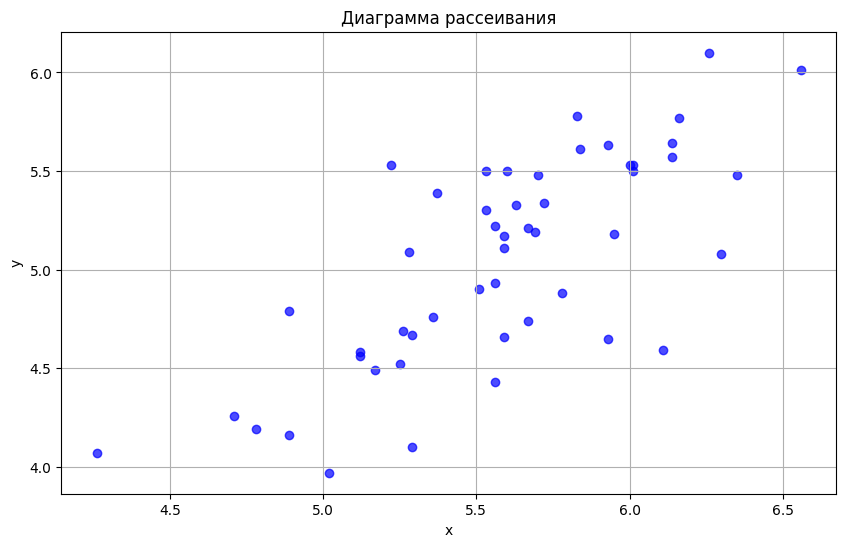

1) Коэффициент корреляции Пирсона: 0.7431
   p-значение: 0.000000

2) Уравнения регрессии:
   Y на X: y = 0.2521 + 0.8585x


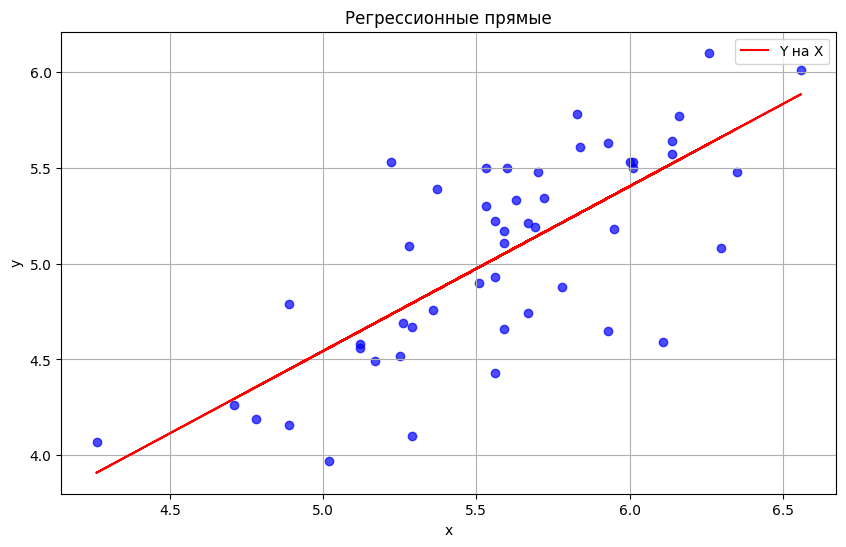


1) Оценка дисперсии ошибок: 0.1325
2) R²: 0.5522

3) Доверительные интервалы параметров:
[[-1.00535913  1.50950628]
 [ 0.63412349  1.0828367 ]]


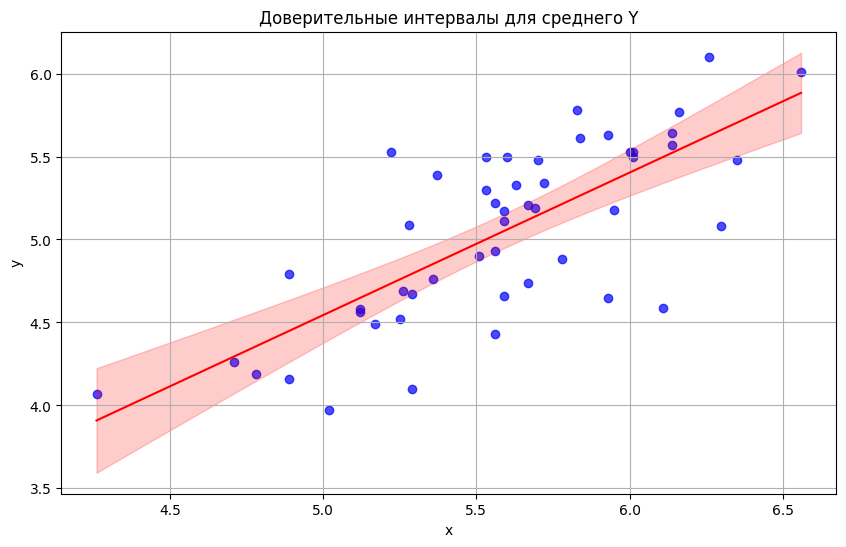


6) F-статистика: 59.1901
   p-значение: 0.000000


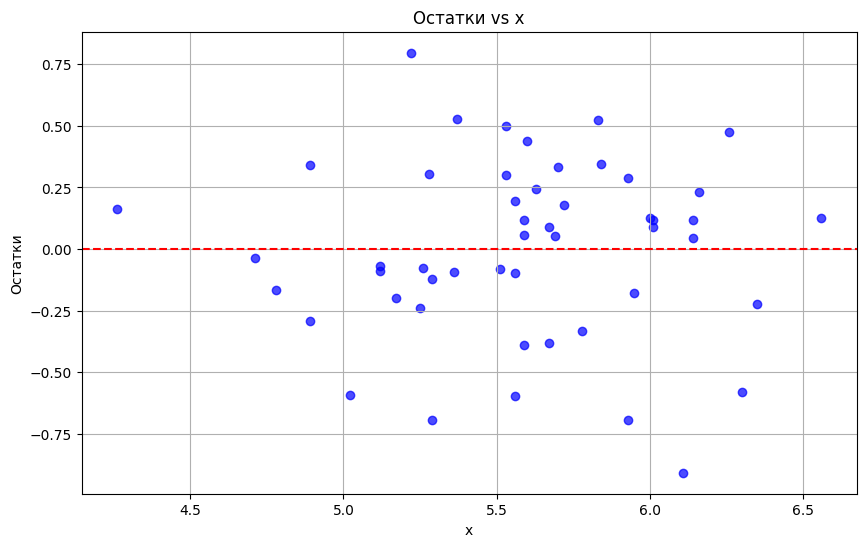

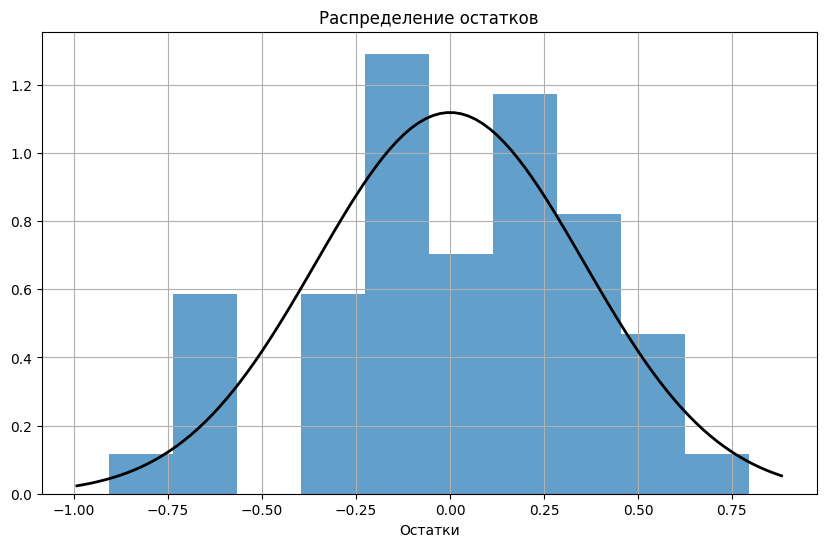


Тест Шапиро-Уилка: W=0.9795, p=0.5302


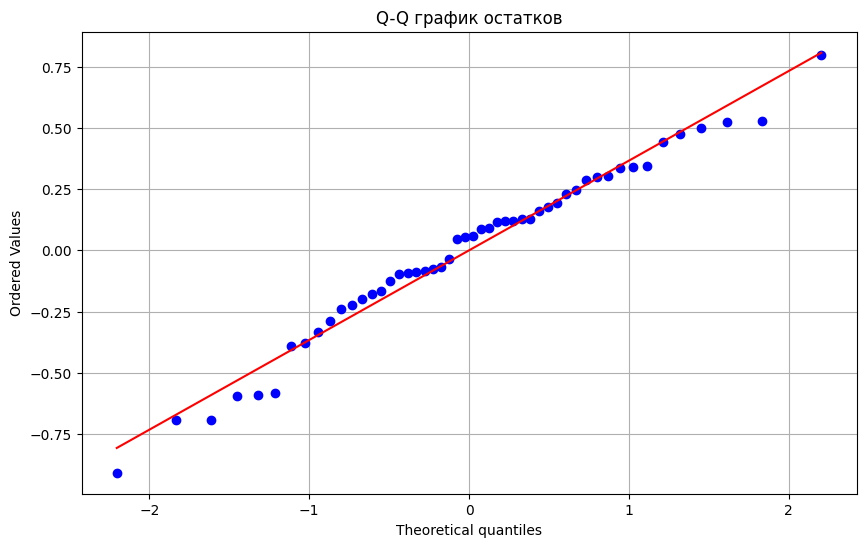


Группированные данные:
            x                   y
        count      mean      mean
group                            
Низкие     17  5.075294  4.577647
Средние    16  5.606250  5.125625
Высокие    17  6.076471  5.442941

Тест Левена: F=0.6198, p=0.5424
ANOVA: F=19.8871, p=0.0000


<ipython-input-1-c53772e8d848>:201: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('group').agg({'x': ['count', 'mean'], 'y': 'mean'}))


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# --------------------------------------------
# Подготовка данных
# --------------------------------------------
data = """
5,29	4,1
4,26	4,07
4,89	4,16
6,35	5,48
5,84	5,61
5,37	5,39
5,72	5,34
6,11	4,59
5,7	5,48
5,36	4,76
5,69	5,19
5,67	4,74
5,26	4,69
5,95	5,18
5,02	3,97
5,25	4,52
6,3	5,08
5,78	4,88
5,93	4,65
5,17	4,49
5,6	5,5
5,59	5,11
5,56	4,93
5,56	5,22
5,12	4,58
6,16	5,77
6,01	5,5
5,22	5,53
5,51	4,9
4,78	4,19
6,01	5,53
5,59	4,66
5,12	4,56
4,89	4,79
5,59	5,17
5,93	5,63
6	5,53
5,67	5,21
6,56	6,01
5,63	5,33
6,26	6,1
5,29	4,67
4,71	4,26
5,28	5,09
6,14	5,64
5,53	5,3
5,56	4,43
6,14	5,57
5,83	5,78
5,53	5,5
"""

# Преобразование данных
data = data.strip().split('\n')
sample = []
for line in data:
    x, y = line.replace(',', '.').split('\t')
    sample.append([float(x), float(y)])
sample = np.array(sample)
x = sample[:, 0]
y = sample[:, 1]
n = len(x)

# --------------------------------------------
# Часть 1: Основной анализ
# --------------------------------------------

# 1. Диаграмма рассеивания и корреляция
plt.figure(figsize=(10,6))
plt.scatter(x, y, color='blue', alpha=0.7)
plt.title("Диаграмма рассеивания")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Расчет корреляции
r = np.corrcoef(x, y)[0,1]
t_stat = r * np.sqrt(n-2)/np.sqrt(1-r**2)
p_val = 2*(1 - stats.t.cdf(abs(t_stat), df=n-2))
print(f"1) Коэффициент корреляции Пирсона: {r:.4f}")
print(f"   p-значение: {p_val:.6f}\n")

# 2. Регрессия вручную
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
b0, b1 = model.params
y_pred = b0 + b1*x

print("2) Уравнения регрессии:")
print(f"   Y на X: y = {b0:.4f} + {b1:.4f}x")

# 3. Визуализация регрессии
plt.figure(figsize=(10,6))
plt.scatter(x, y, color='blue', alpha=0.7)
plt.plot(x, y_pred, color='red', label='Y на X')
plt.title("Регрессионные прямые")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------
# Часть 2: Оценка качества регрессии
# --------------------------------------------

# 1. Дисперсия ошибок
residuals = y - y_pred
s2 = np.sum(residuals**2)/(n-2)
print(f"\n1) Оценка дисперсии ошибок: {s2:.4f}")

# 2. Коэффициент детерминации
ss_total = np.sum((y - np.mean(y))**2)
r2 = 1 - np.sum(residuals**2)/ss_total
print(f"2) R²: {r2:.4f}")

# 3-4. Доверительные интервалы
conf_int = model.conf_int(alpha=0.05)
print("\n3) Доверительные интервалы параметров:")
print(conf_int)

# 5. Доверительные интервалы для среднего Y
x0 = np.linspace(min(x), max(x), 100)
X0 = sm.add_constant(x0)
pred = model.get_prediction(X0)
ci = pred.conf_int()

plt.figure(figsize=(10,6))
plt.scatter(x, y, color='blue', alpha=0.7)
plt.plot(x0, pred.predicted_mean, color='red')
plt.fill_between(x0, ci[:,0], ci[:,1], color='red', alpha=0.2)
plt.title("Доверительные интервалы для среднего Y")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

# 6. Проверка значимости регрессии
print(f"\n6) F-статистика: {model.fvalue:.4f}")
print(f"   p-значение: {model.f_pvalue:.6f}")

# --------------------------------------------
# Анализ остатков
# --------------------------------------------

# График остатков
plt.figure(figsize=(10,6))
plt.scatter(x, residuals, color='blue', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Остатки vs x")
plt.xlabel("x")
plt.ylabel("Остатки")
plt.grid(True)
plt.show()

# Гистограмма остатков
plt.figure(figsize=(10,6))
plt.hist(residuals, bins=10, density=True, alpha=0.7)
mu, std = stats.norm.fit(residuals)
xmin, xmax = plt.xlim()
x_norm = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x_norm, mu, std)
plt.plot(x_norm, p, 'k-', linewidth=2)
plt.title("Распределение остатков")
plt.xlabel("Остатки")
plt.grid(True)
plt.show()

# Тест нормальности
shapiro_test = stats.shapiro(residuals)
print(f"\nТест Шапиро-Уилка: W={shapiro_test[0]:.4f}, p={shapiro_test[1]:.4f}")

# Q-Q plot
plt.figure(figsize=(10,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q график остатков")
plt.grid(True)
plt.show()

# --------------------------------------------
# Проверка адекватности модели
# --------------------------------------------

# Группировка данных
df = pd.DataFrame({'x': x, 'y': y})
df['group'] = pd.qcut(df['x'], q=3, labels=['Низкие', 'Средние', 'Высокие'])

print("\nГруппированные данные:")
print(df.groupby('group').agg({'x': ['count', 'mean'], 'y': 'mean'}))

# Тест Левена
levene_test = stats.levene(
    df[df['group'] == 'Низкие']['y'],
    df[df['group'] == 'Средние']['y'],
    df[df['group'] == 'Высокие']['y']
)

# ANOVA
anova_test = stats.f_oneway(
    df[df['group'] == 'Низкие']['y'],
    df[df['group'] == 'Средние']['y'],
    df[df['group'] == 'Высокие']['y']
)

print(f"\nТест Левена: F={levene_test.statistic:.4f}, p={levene_test.pvalue:.4f}")
print(f"ANOVA: F={anova_test.statistic:.4f}, p={anova_test.pvalue:.4f}")